CAR PRICE ANALYSIS


A machine learning model can help:
* Sellers price their cars correctly
* Buyers identify fair prices
* The market place improve customer experience





In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load dataset
df = pd.read_csv('/content/Car_data_jtrjuw.csv')


In [ ]:
# Display first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Display last 5 rows
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
# Target variable
target = "Selling_Price"

In [ ]:
# Features
features = df.drop("Selling_Price", axis=1).columns
print(features)

Index(['Car_Name', 'Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')


In [ ]:
# Data shape
print(df.shape)

(301, 9)


In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
# Missing Values
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
# Summary Statistics
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


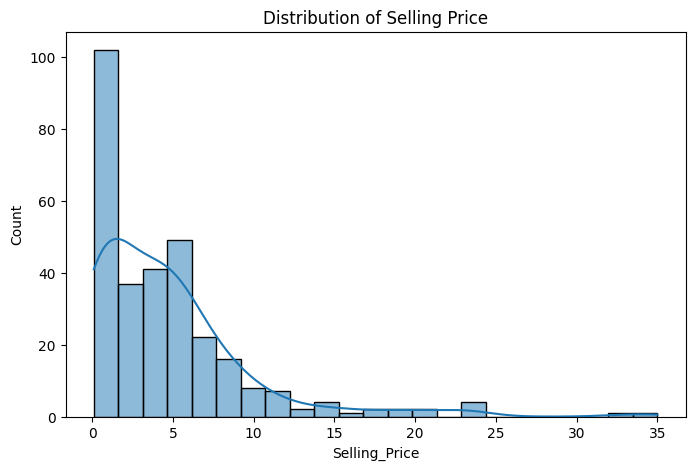

In [ ]:
# Distribution of Selling Price
plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'], kde=True)
plt.title("Distribution of Selling Price")
plt.show()

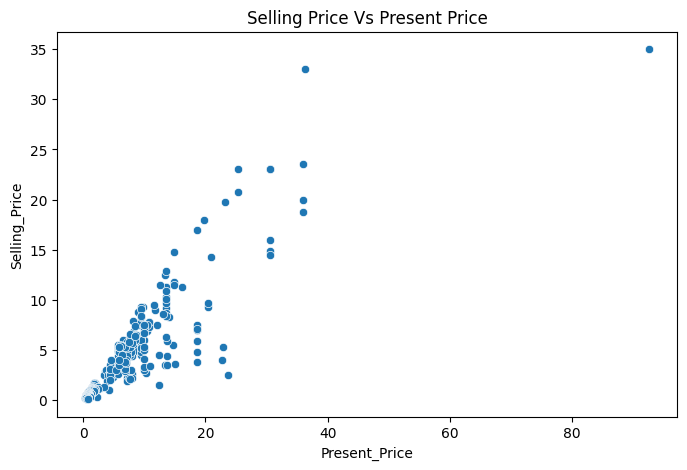

In [ ]:
# Selling Price Vs Present Price
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Present_Price',
    y='Selling_Price',
    data=df
)
plt.title("Selling Price Vs Present Price")
plt.show()
# Cars with higher present prices generally have higher selling prices.

# OBSERVATION
Cars with higher present prices generally have higher selling prices.

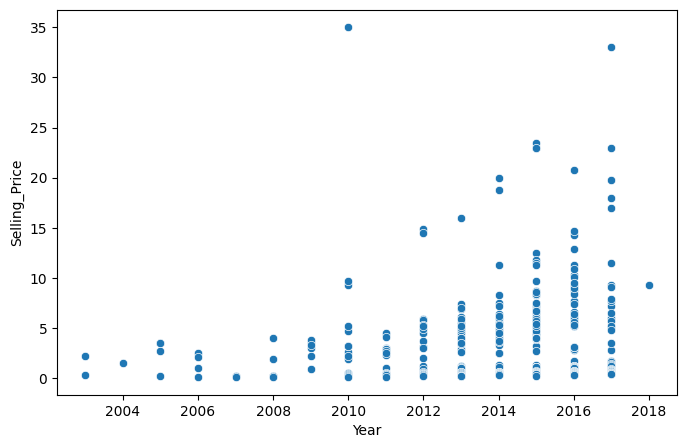

In [ ]:
# Selling Price vs Year
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Year',
    y='Selling_Price',
    data=df
)
plt.show()

# OBSERVATION
Newer cars tend to sell for higher prices.

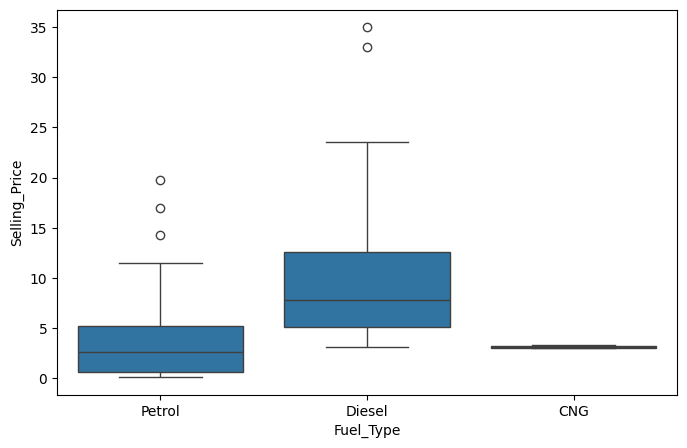

In [ ]:
# Selling Price by Fuel Type
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Fuel_Type',
    y='Selling_Price',
    data=df
)
plt.show()

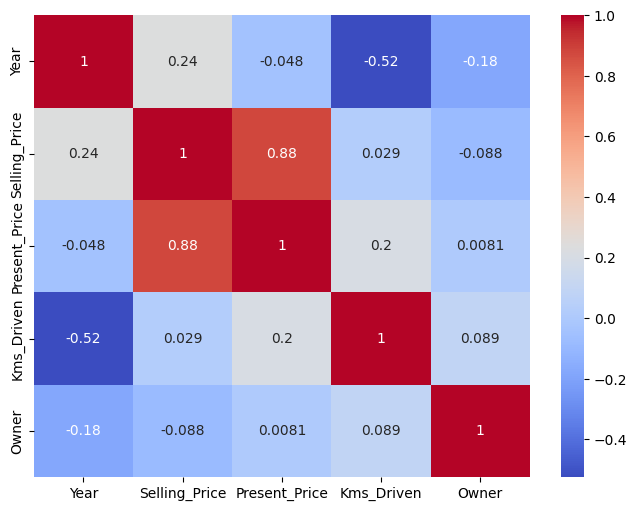

In [ ]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

Data Processing

In [ ]:
# Encode Categorical Values
le = LabelEncoder()

categorical_cols = [
    'Car_Name',
    'Fuel_Type',
    'Seller_Type',
    'Transmission'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
# Features and Target

In [ ]:
# Features and Targets
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Model Building

In [ ]:
# Linear Regression
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predictions
y_pred = model.predict(X_test)

In [ ]:
display(y_pred)

array([ 2.97644454,  8.32917948,  6.0123036 , -1.37805202,  9.280705  ,
        7.07182191,  1.30737897,  0.73704551,  1.38659732,  7.1223663 ,
        8.69582371,  0.54409582,  8.53813757,  3.53213997,  6.4585752 ,
        3.03568205,  0.42300154, 10.91771943,  1.74585163,  2.29070109,
        0.3757878 ,  7.77083406,  6.16785401,  2.59945071,  0.85198574,
        3.69656298,  5.35628073,  2.8270644 ,  2.11562213,  1.72091397,
        0.42471049,  8.82857611, -0.60822986,  2.24825562,  8.22761075,
        4.57915199,  7.36951231,  7.70918431,  2.84738916,  8.10775746,
        3.97554366,  4.37311336,  4.40474252,  0.54819228,  6.90943311,
        0.46052629,  7.44143577, 11.46855716,  3.1251384 ,  4.93975371,
        6.80801367,  2.15440015, 20.55469303, 16.78533884,  7.09045708,
        9.85749899,  4.48034716,  8.65824873,  1.84431357,  7.63938103,
        0.21185192])

Model Evaluation

In [ ]:
# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 1.2142339415017116


In [ ]:
#RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 1.8800848570469801


In [ ]:
#R² Score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.8465539666864582


# **INTERPRETATION**
The model explains approximately:
84.7% of the variation in selling prices.
This is a strong result for a simple Linear Regression model.

In [ ]:
# Prediction prices for 5 cars
sample_cars = X.head(5)

predictions = model.predict(sample_cars)

result = sample_cars.copy()
result['Predicted_Price'] = predictions

print(result)

   Car_Name  Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  \
0        90  2014           5.59       27000          2            0   
1        93  2013           9.54       43000          1            0   
2        68  2017           9.85        6900          2            0   
3        96  2011           4.15        5200          2            0   
4        92  2014           6.87       42450          1            0   

   Transmission  Owner  Predicted_Price  
0             1      0         3.916968  
1             1      0         6.534799  
2             1      0         7.065328  
3             1      0         2.299339  
4             1      0         5.726901  


FEATURE IMPORTANCE ANALYSIS

In [ ]:
#Feature Importance Analysis
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
2,Present_Price,0.440549
1,Year,0.361972
3,Kms_Driven,-0.000006
0,Car_Name,-0.003307
7,Owner,-0.909505
5,Seller_Type,-1.307605
4,Fuel_Type,-1.339473
6,Transmission,-1.639444


Most Influential Features Affecting Car Price

Based on the Linear Regression model, several factors were found to significantly influence the selling price of a car.

1. Present Price

The Present Price of a vehicle was the strongest predictor of its selling price. Cars with a higher current market value generally commanded higher resale prices. This relationship was expected because the selling price of a used car is largely influenced by its original and current market worth.

2. Year of Manufacture

The Year of manufacture had a positive influence on selling price. Newer vehicles tended to have higher resale values because they typically experience less wear and tear, incorporate newer technology, and have a longer remaining useful life compared to older vehicles.

3. Transmission Type

The Transmission type had a strong effect on vehicle pricing. In many cases, automatic transmission vehicleswere sold at higher prices than manual transmission vehicles due to greater consumer preference and convenience.

4. Fuel Type

The Fuel Type of a vehicle also significantly affected its selling price. Differences in fuel efficiency, operating costs, and consumer demand for petrol, diesel, or CNG vehicles contributed to variations in resale value.

5. Seller Type

The Seller Type (Dealer or Individual) was another important factor. Vehicles sold through dealers often attracted higher prices because buyers may perceive dealer-sold vehicles as more reliable or better maintained.

6. Number of Previous Owners

The Owner variable had a moderate influence on price. Cars with fewer previous owners generally retained higher resale values because they are often perceived as being in better condition and having a more reliable ownership history.

7. Kilometers Driven

The Kms_Driven feature showed a slight negative relationship with selling price. As the distance driven by a vehicle increased, its selling price generally decreased. Higher mileage is often associated with increased wear and maintenance requirements, making such vehicles less attractive to buyers.

Overall Insight

The analysis revealed that the current market value of the car (Present Price) and the age of the vehicle (Year) were the most important factors in determining resale price. While factors such as fuel type, transmission, and seller type also played meaningful roles, the number of kilometers driven and previous ownership history had comparatively smaller effects on the final selling price. These findings suggest that a car's market value and age are the primary drivers of its resale value in the used car market.

In [ ]:
# Saved Cleaned Dataset
df.to_csv(
    "cleaned_car_dataset.csv",
    index=False
)

print("Dataset saved successfully.")


Dataset saved successfully.
